<a href="https://colab.research.google.com/github/martatolos/eae-dsaa/blob/main/svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Machines (SVMs) using Python - Exercise

### Prerequisite

Before we begin, we have to install the necessary python packages

In [1]:
%pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 seaborn==0.13.2

Note: you may need to restart the kernel to use updated packages.


### Exercise: classify hand writings

In this exercise, we'll use the MNIST dataset,  a classic benchmark dataset in machine learning and computer vision. It contains:

- 70,000 grayscale images of handwritten digits (0 to 9)
- Each image is 8x8 / 28×28 pixels
- Labels correspond to the digit shown in the image

In [2]:
# Load MNIST dataset (this is actually the 8x8 version; for full 28x28 see below)
from sklearn import datasets

size = 8
digits = datasets.load_digits()
X, y = digits.data, digits.target

# ------------------
from sklearn.datasets import fetch_openml
#size = 28
#digits = fetch_openml('mnist_784', version=1, as_frame=False)
#X, y = digits.data / 255.0, digits.target.astype(int)

# We only use 2.5k of the points (otherwise training will take too long)
# X = X[:2500]
# y = y[:2500]

In [3]:
# Let's look at our features
X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [4]:
# ... and target
y

array([0, 1, 2, ..., 8, 9, 8])

The feature values are difficult to interpret. Let's visualize the numbers instead:

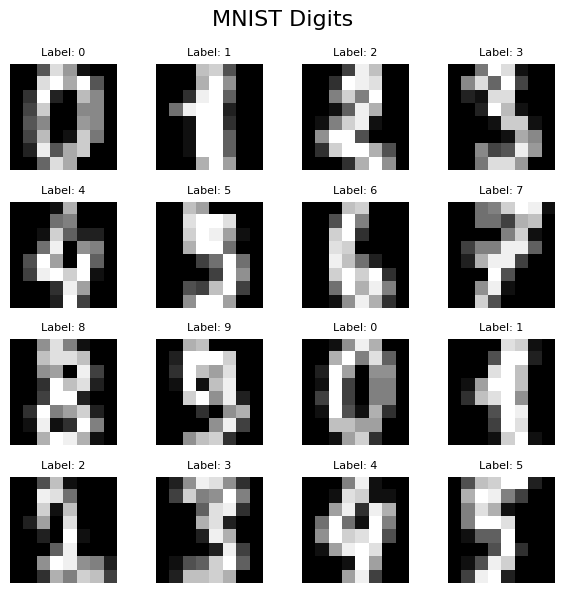

In [5]:
from matplotlib import pyplot as plt

# Number of images to display
num_images = 16
rows, cols = 4, 4  # 4x4 grid

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
fig.suptitle("MNIST Digits", fontsize=16)

for i in range(num_images):
    ax = axes[i // cols, i % cols]
    ax.imshow(X[i].reshape(size, size), cmap="gray")
    ax.set_title(f"Label: {y[i]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

**Now it's your turn:**
- Split the data into a train, validation and test set
- Train a classifier of your choice (e.g. decision tree, logistic regression, SVM)
- Evaluate the performance of the classifier
- Analyze the prediction results

#### Imports

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#### Step 1 — Train / validation / test split

Reserve 20 % for testing and another 20 % of the remainder for validation. Use stratification to keep class proportions balanced across all three splits.

In [7]:
# 1. Split into train, validation, and test sets
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

print(f"Train size: {len(X_train)} / Validation size: {len(X_val)} / Test size: {len(X_test)}")

Train size: 1149 / Validation size: 288 / Test size: 360


#### Step 2 — Train

Wrap `StandardScaler` and `SVC` in a pipeline so scaling is always applied consistently before the classifier.

In [16]:
# 2. Train a SVM classifier using a pipeline with feature scaling
pipeline = Pipeline([("scaler", StandardScaler()), ("dt", DecisionTreeClassifier())])
#pipeline = Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="linear"))])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('dt', DecisionTreeClassifier())])

#### Step 3 — Evaluate on validation set

Use the validation set to assess performance before touching the test set. The classification report breaks down precision, recall, and F1 per digit.

In [17]:
# 3. Evaluate performance on validation set
y_val_pred = pipeline.predict(X_val)
print(f"Validation accuracy: {accuracy_score(y_val, y_val_pred):.4f}")

report = classification_report(y_val, y_val_pred)
print("\nClassification report (validation set):\n", report)

Validation accuracy: 0.8438

Classification report (validation set):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       0.87      0.90      0.88        29
           2       0.80      0.86      0.83        28
           3       0.79      0.93      0.86        29
           4       0.80      0.69      0.74        29
           5       0.83      0.83      0.83        29
           6       0.86      0.83      0.84        29
           7       0.79      0.90      0.84        29
           8       0.88      0.75      0.81        28
           9       0.85      0.76      0.80        29

    accuracy                           0.84       288
   macro avg       0.85      0.84      0.84       288
weighted avg       0.85      0.84      0.84       288



#### Step 4 — Evaluate on test set

Final, unbiased evaluation on held-out data. The confusion matrix shows which digits are mistaken for which.

Test accuracy: 0.7861


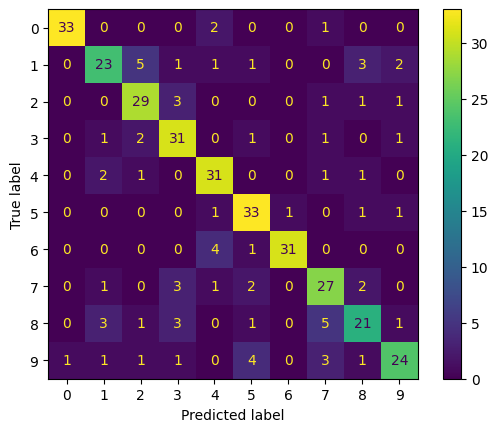

In [18]:
# 4. Evaluate on test set
y_test_pred = pipeline.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred):.4f}")

conf_mat = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=digits.target_names)
disp.plot()

#### Step 5 — Visualize predictions

Inspect a sample of correct predictions alongside every misclassification to understand where the model struggles.

Correct predictions: 283  |  Errors: 77


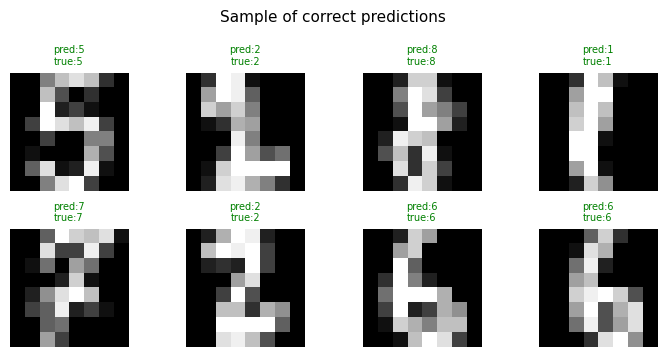

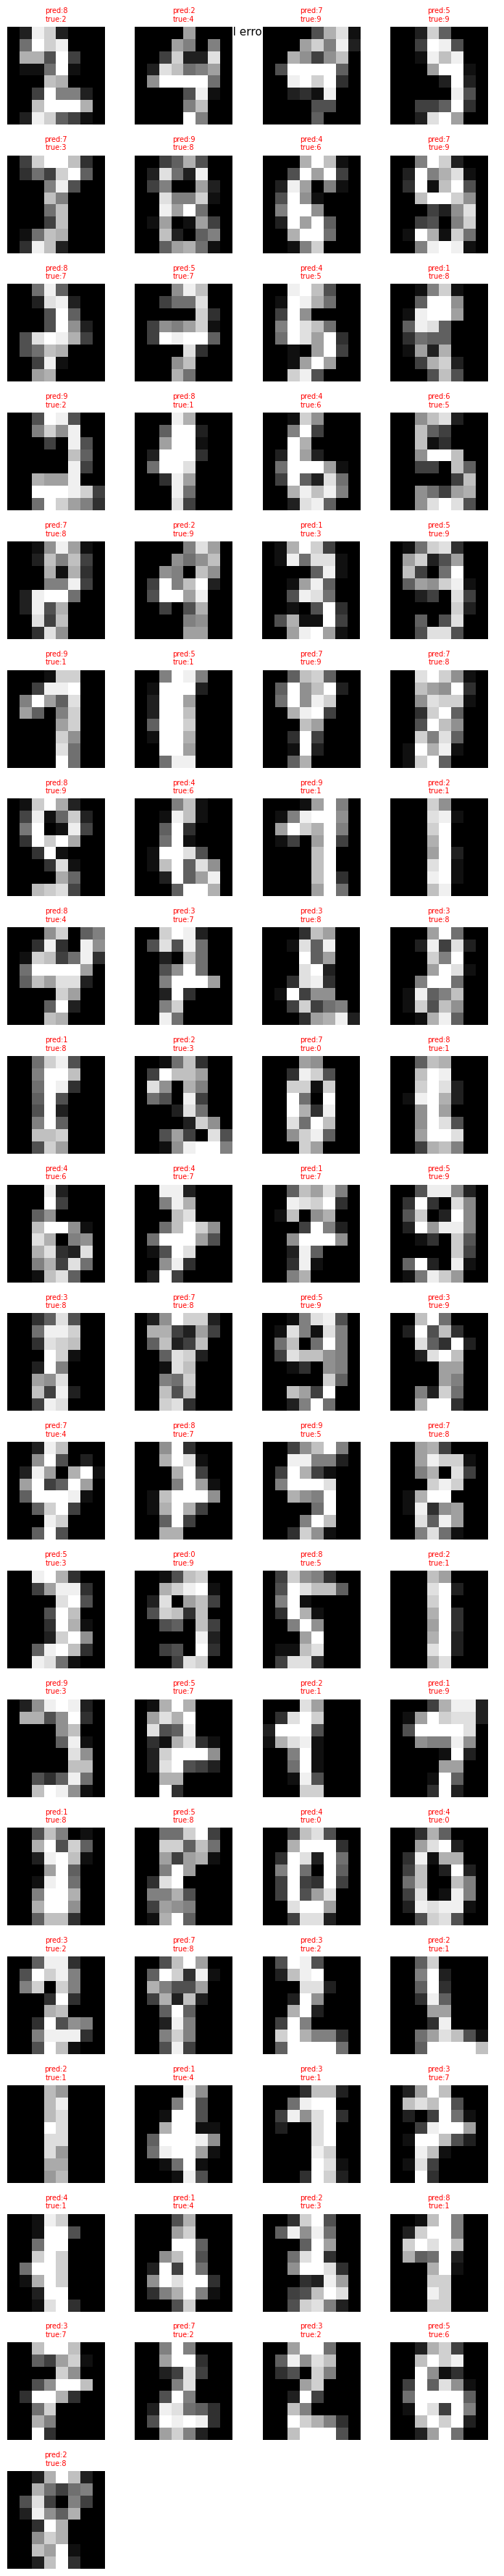

In [19]:
def plot_predictions(
    X: np.ndarray,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    image_size: int,
    n_correct: int = 8,
    cols: int = 4,
) -> None:
    """Display a sample of correct predictions and all errors side by side."""
    correct_idx = [i for i in range(len(X)) if y_pred[i] == y_true[i]]
    error_idx   = [i for i in range(len(X)) if y_pred[i] != y_true[i]]

    print(f"Correct predictions: {len(correct_idx)}  |  Errors: {len(error_idx)}")

    def _plot_grid(indices: list[int], title: str, color: str) -> None:
        if not indices:
            print(f"No {title.lower()}.")
            return
        n_rows = (len(indices) + cols - 1) // cols
        fig, axes = plt.subplots(n_rows, cols, figsize=(cols * 1.8, n_rows * 1.8))
        axes = np.array(axes).reshape(n_rows, cols)
        for i, idx in enumerate(indices):
            ax = axes[i // cols, i % cols]
            ax.imshow(X[idx].reshape(image_size, image_size), cmap="gray")
            ax.set_title(f"pred:{y_pred[idx]}\ntrue:{y_true[idx]}", fontsize=7, color=color)
            ax.axis("off")
        for j in range(len(indices), n_rows * cols):
            axes[j // cols, j % cols].axis("off")
        fig.suptitle(title, fontsize=11)
        plt.tight_layout()
        plt.show()

    _plot_grid(correct_idx[:n_correct], "Sample of correct predictions", "green")
    _plot_grid(error_idx,               "All errors",                    "red")


# 5. Visualize predictions
plot_predictions(X_test, y_test, y_test_pred, image_size=size)

#### Grid search — find the best hyperparameters

Exhaustively try combinations of `C`, `kernel`, and `gamma` (plus `degree` for the polynomial kernel) using 5-fold cross-validation.

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        "svc__C":      [0.1, 1, 10],
        "svc__kernel": ["linear", "rbf"],
        "svc__gamma":  ["scale", "auto"],
    },
    {
        "svc__C":      [0.1, 1, 10],
        "svc__kernel": ["poly"],
        "svc__gamma":  ["scale", "auto"],
        "svc__degree": [2, 3, 4],
    },
]

grid_search = GridSearchCV(
    estimator=Pipeline([("scaler", StandardScaler()), ("svc", SVC())]),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best parameters:  ", grid_search.best_params_)
print("Best CV accuracy: ", round(grid_search.best_score_, 4))

Best parameters:   {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best CV accuracy:  0.9852


#### Grid search — evaluate the best classifier

Test accuracy: 0.9833

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      0.97      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       1.00      1.00      1.00        37
           6       0.97      1.00      0.99        36
           7       0.95      1.00      0.97        36
           8       1.00      0.94      0.97        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



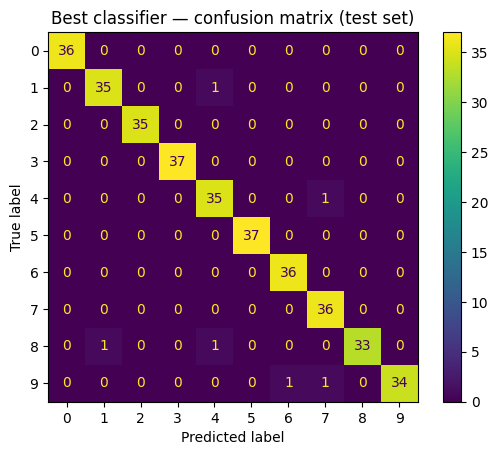

In [13]:
# Evaluate the best classifier on the test set
y_gs_pred = grid_search.predict(X_test)

print(f"Test accuracy: {accuracy_score(y_test, y_gs_pred):.4f}\n")
print(classification_report(y_test, y_gs_pred))

gs_conf_mat = confusion_matrix(y_test, y_gs_pred)
ConfusionMatrixDisplay(confusion_matrix=gs_conf_mat, display_labels=digits.target_names).plot()
plt.title("Best classifier — confusion matrix (test set)")
plt.show()

#### Grid search — all results ranked by cross-validation score

In [14]:
# CV results ordered by test score
import pandas as pd

cv_results = pd.DataFrame(grid_search.cv_results_)[
    ["rank_test_score", "param_svc__kernel", "param_svc__C", "param_svc__gamma",
     "param_svc__degree", "mean_test_score", "std_test_score", "mean_fit_time"]
].sort_values("rank_test_score").reset_index(drop=True)

display(cv_results)

,rank_test_score,param_svc__kernel,param_svc__C,param_svc__gamma,param_svc__degree,mean_test_score,std_test_score,mean_fit_time
0,1,rbf,10.0,scale,NaN,0.985210,0.007575,0.023300
1,2,rbf,10.0,auto,NaN,0.982597,0.007269,0.021502
2,3,poly,10.0,auto,3.0,0.981713,0.010098,0.023824
3,3,poly,10.0,scale,3.0,0.981713,0.010098,0.025554
4,5,poly,10.0,scale,2.0,0.980854,0.004428,0.022059
5,5,poly,10.0,auto,2.0,0.980854,0.004428,0.020406
6,7,rbf,1.0,scale,NaN,0.978246,0.007769,0.021548
7,8,rbf,1.0,auto,NaN,0.978242,0.008250,0.022324
8,9,linear,0.1,scale,NaN,0.977380,0.010055,0.040574
9,9,linear,0.1,auto,NaN,0.977380,0.010055,0.023764


#### Grid search — visualize predictions of the best classifier

Correct predictions: 354  |  Errors: 6


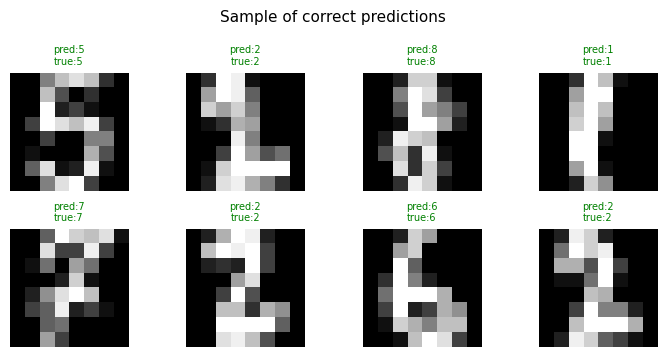

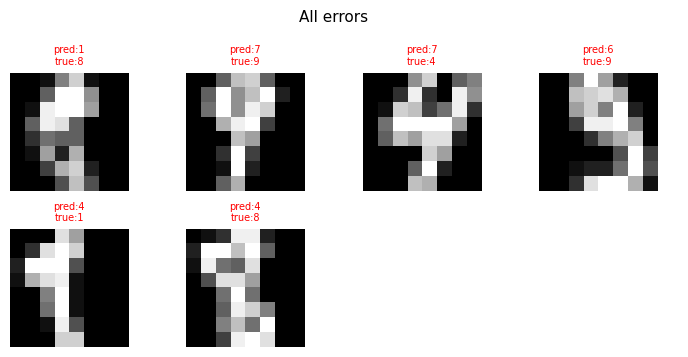

In [15]:
plot_predictions(X_test, y_test, y_gs_pred, image_size=size)